# Exploratory Data Analysis

Household electricity consumption, aggregated to hourly resolution. Target variable: `Global_active_power` (kWh per hour). This notebook loads the raw series, audits quality, cleans and resamples, builds leakage-free calendar features, renders the EDA figure set and runs the stationarity and seasonality tests that the modelling phase relies on.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path
import pandas as pd
sys.path.insert(0, str(Path.cwd().parent))
from src import data_loader, data_quality, data_cleaning, feature_engineering, eda, stats_tests
pd.set_option('display.width', 120)
ROOT_FIG = Path.cwd().parent / 'reports' / 'figures' / 'eda'

## Load and quality audit

In [2]:
raw = data_loader.load_or_download_data()
print(raw.shape)
raw.head()

(2075259, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
timestamp,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.839996,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.630005,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.289993,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.740005,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.679993,15.8,0.0,1.0,17.0


In [3]:
report = data_quality.audit(raw)
print(report.summary())

rows: 2,075,259
missing rate: 1.2518%
duplicated timestamps: 0
timestamp gaps: 0 (largest 0 min)
coverage vs expected grid: 100.0000%
range violations: {'voltage_out_of_band': 4010, 'Global_active_power_negative': 0, 'Global_reactive_power_negative': 0, 'Global_intensity_negative': 0}


## Clean, resample to hourly and build features

In [4]:
hourly = data_cleaning.clean_and_resample(raw)
features = feature_engineering.build_features(hourly)
print('hourly:', hourly.shape, '| features:', features.shape)
print('residual NaN:', int(hourly.isna().sum().sum()))
hourly[['Global_active_power']].describe()

hourly: (34589, 7) | features: (34589, 20)
residual NaN: 0


,Global_active_power
count,34589.000000
mean,1.090207
std,0.894208
min,0.046733
25%,0.342867
50%,0.803100
75%,1.578700
max,6.560534


## EDA figures

All figures are written to `reports/figures/eda/` at 120 dpi.

In [5]:
paths = eda.generate_all(hourly)
[p.name for p in paths]

['01_full_series.png',
 '02_zoom_week_day.png',
 '03_boxplots.png',
 '04_rolling_stats.png',
 '05_acf_pacf.png',
 '06_stl_daily.png',
 '07_stl_weekly.png',
 '08_distribution.png',
 '09_load_heatmap.png',
 '10_monthly_profile.png']

### Full series

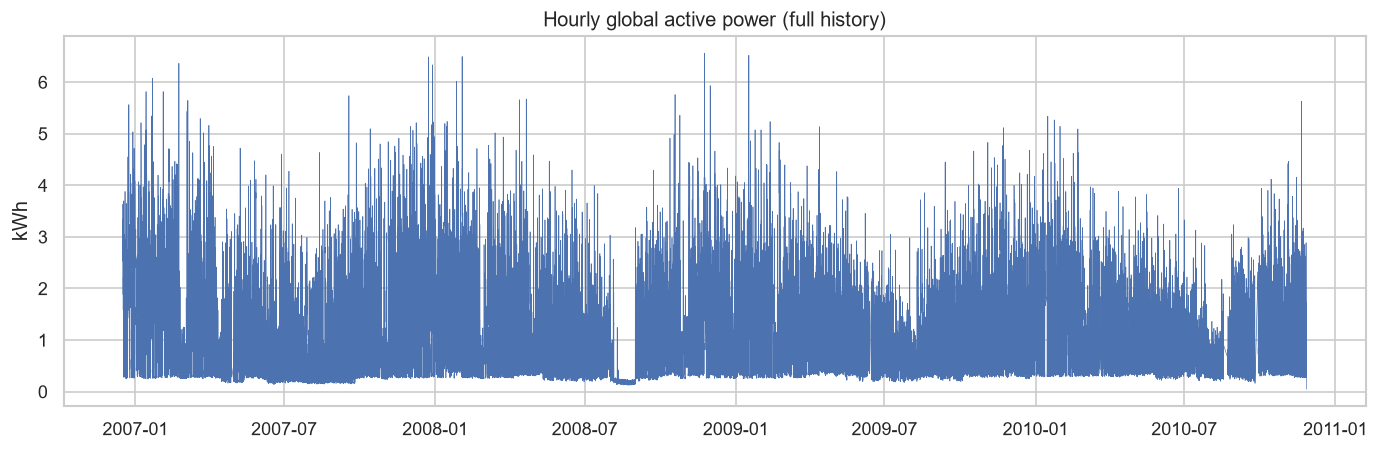

In [6]:
from IPython.display import Image
Image(str(paths[0]))

### Weekly load profile

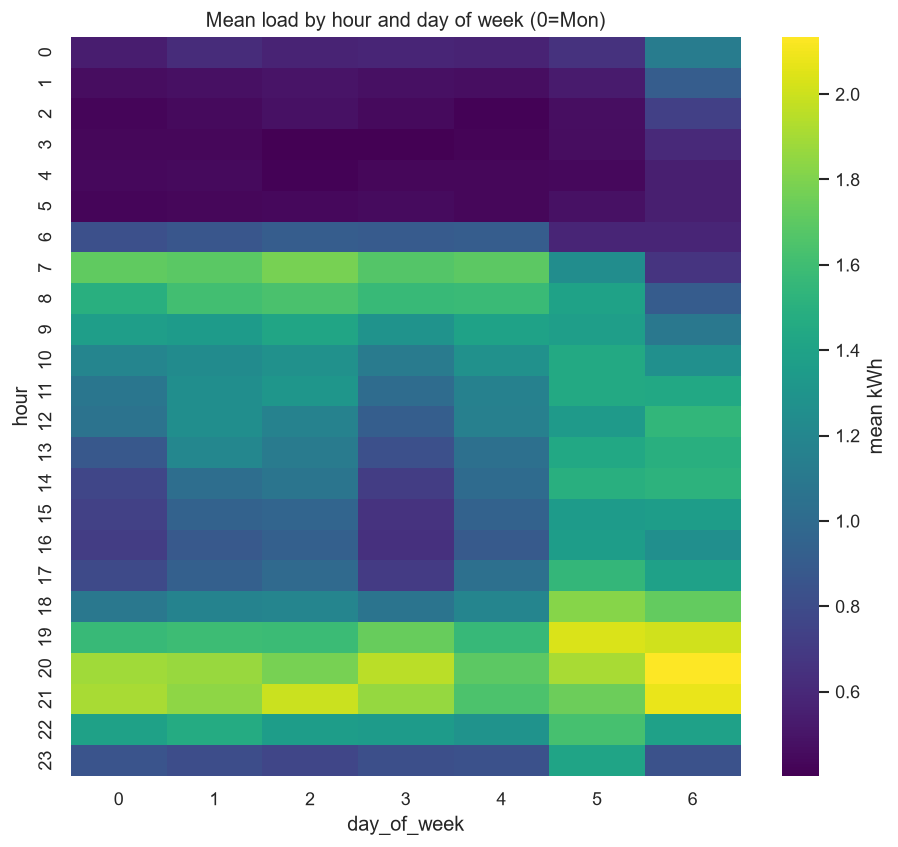

In [7]:
Image(str(ROOT_FIG / '09_load_heatmap.png'))

### ACF / PACF

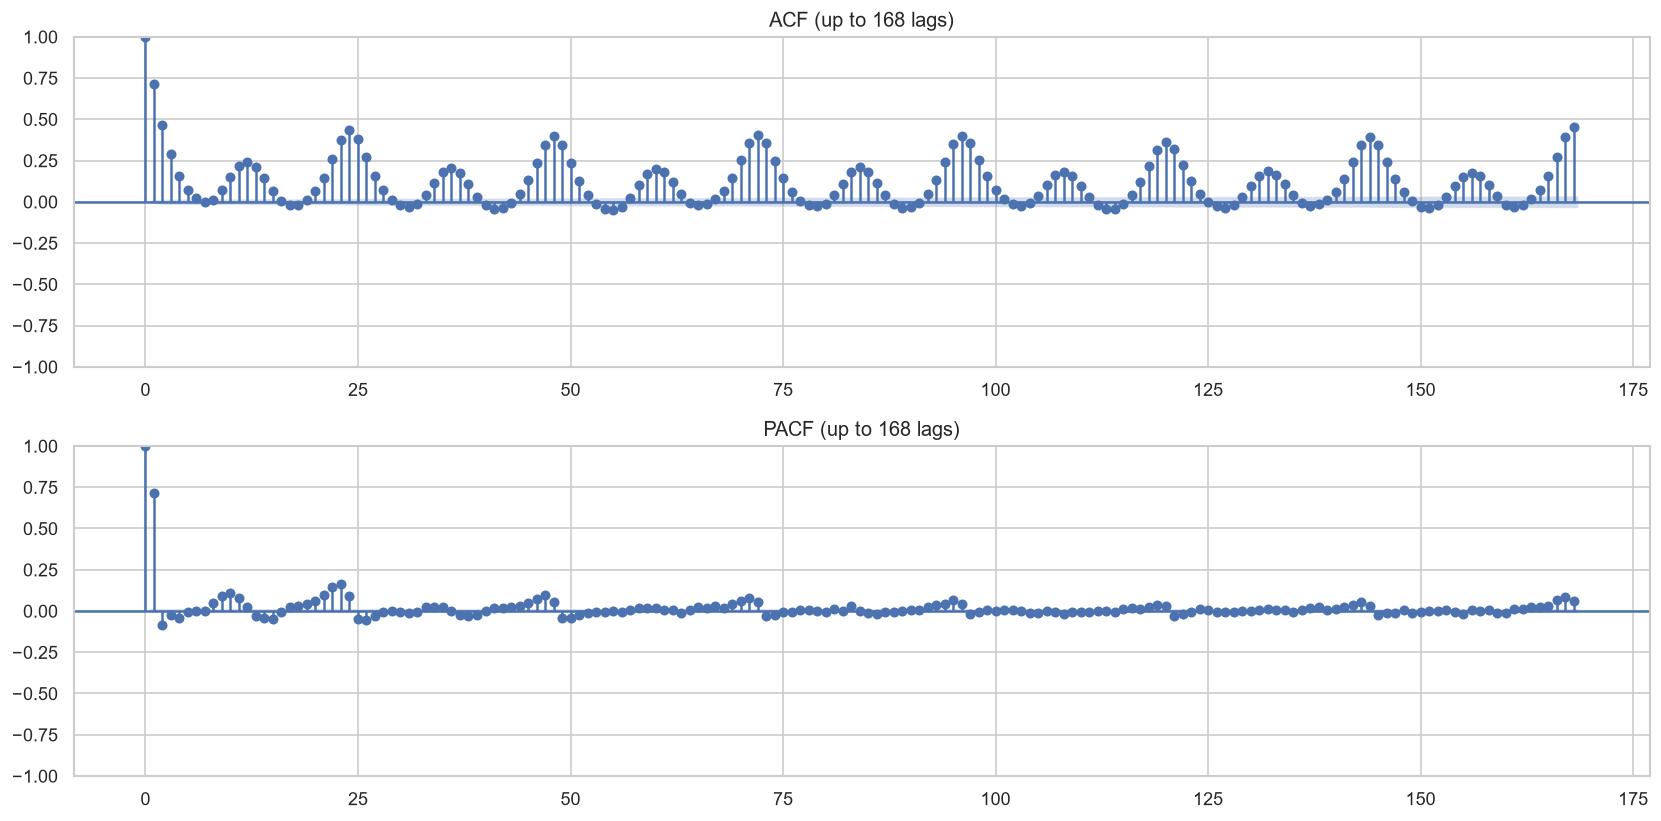

In [8]:
Image(str(paths[4]))

## Statistical tests

In [9]:
series = hourly['Global_active_power']
stat = stats_tests.stationarity_raw_and_differenced(series)
for k, r in stat.items():
    print(f'[{r.label}] ADF p={r.adf_pvalue:.3g} | KPSS p={r.kpss_pvalue:.3g} | {r.verdict}')

C:\Claude\Projects\time_series_forecasting_project\src\stats_tests.py:60: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pvalue, *_ = kpss(series, regression="c", nlags="auto")


[raw] ADF p=9.56e-27 | KPSS p=0.01 | inconclusive
[seasonal_diff_24] ADF p=0 | KPSS p=0.1 | stationary


C:\Claude\Projects\time_series_forecasting_project\src\stats_tests.py:60: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pvalue, *_ = kpss(series, regression="c", nlags="auto")


In [10]:
for factor in ('hour', 'day_of_week'):
    kw = stats_tests.kruskal_by(series, factor)
    print(f'[{factor}] H={kw.statistic:.1f} p={kw.pvalue:.3g} significant={kw.significant}')

[hour] H=8842.5 p=0 significant=True
[day_of_week] H=239.3 p=0 significant=True


In [11]:
stats_tests.ljung_box(series)

,lb_stat,lb_pvalue
24,50757.386841,0.0
168,196057.032939,0.0
720,593901.964916,0.0


## Findings

- Consumption is dominated by a strong daily cycle; a secondary weekly cycle separates weekday from weekend routines.
- The raw series is not cleanly stationary (ADF and KPSS disagree); the lag-24 seasonal difference is stationary under both tests.
- Autocorrelation stays highly significant out to 720 lags, so recent history is strongly predictive and lag features are well justified.